# =============================================================================
# Saudi Cost of Living Analysis — CPI Trends 2018–2023
# Author: Maimona Turkistani
# Tools: Python, pandas, Matplotlib, Seaborn
# Data: Based on GASTAT Consumer Price Index methodology
# =============================================================================
# ── CELL 1: Import libraries ──────────────────────────────────────────────────

# Saudi Cost of Living Analysis
## CPI Trends Across Food, Housing, Transport & Education (2018–2023)

### Background
The Consumer Price Index (CPI) measures how the price of a fixed basket of
goods and services changes over time. A CPI of 110 means prices are 10% higher
than in the base year (2018 = 100). This analysis examines how the cost of
living evolved across Riyadh, Jeddah, and Dammam — covering the pre-COVID
period, the pandemic shock (2020), the VAT tripling in July 2020, and the
global inflation wave of 2022.

### Key Questions
1. Which spending category inflated fastest overall?
2. How did COVID-19 and the 2020 VAT increase affect prices?
3. Which city became most expensive by 2023?
4. Did inflation hit all categories equally?

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Global style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

CITY_COLORS = {
    'Riyadh': '#1A5276',
    'Jeddah': '#D35400',
    'Dammam': '#1E8449'
}

CAT_COLORS = {
    'food':       '#E74C3C',
    'housing':    '#1A5276',
    'transport':  '#F39C12',
    'education':  '#8E44AD',
    'healthcare': '#27AE60',
    'clothing':   '#2E86C1',
}

print("✓ Libraries loaded successfully")


✓ Libraries loaded successfully


# ── CELL 2: Load & inspect the data ──────────────────────────────────────────
"""
## Step 1 — Load & Inspect the Dataset

The dataset contains quarterly CPI readings from 2018 to 2023 for three
major Saudi cities: Riyadh, Jeddah, and Dammam. Each row records the index
value for six spending categories plus an overall CPI figure.

Base year = 2018 (index starts near 100). All values are index points,
not percentage changes.
"""

In [18]:

df = pd.read_csv('saudi_cpi_data.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nCities:", df['city'].unique())
print("Years:", sorted(df['year'].unique()))
print("Quarters:", df['quarter'].unique())

Dataset shape: (72, 10)

First 5 rows:
   year quarter    city   food  housing  transport  education  healthcare  \
0  2018      Q1  Riyadh  102.1    101.3      100.8      100.2       100.5   
1  2018      Q2  Riyadh  102.8    101.5      101.0      100.2       100.7   
2  2018      Q3  Riyadh  103.2    101.8      101.3      100.4       100.9   
3  2018      Q4  Riyadh  103.9    102.1      101.5      100.4       101.1   
4  2019      Q1  Riyadh  104.3    102.3      101.6      100.6       101.3   

   clothing  overall_cpi  
0     101.1        101.2  
1     101.3        101.6  
2     101.4        101.9  
3     101.6        102.3  
4     101.7        102.5  

Data types:
year             int64
quarter            str
city               str
food           float64
housing        float64
transport      float64
education      float64
healthcare     float64
clothing       float64
overall_cpi    float64
dtype: object

Missing values:
year           0
quarter        0
city           0
food       

# ── CELL 3: Clean & engineer features ────────────────────────────────────────
"""
## Step 2 — Clean & Engineer Features

We create two additional columns:
- `period`: a sortable string label (e.g. "2020-Q2") for time-axis plotting
- `date`: a proper datetime object using the first month of each quarter

We also calculate the **percentage change from base year (2018 Q1)**
for each city–category combination, which makes comparisons fair
regardless of starting index values.
"""

In [19]:
quarter_month = {'Q1': '01', 'Q2': '04', 'Q3': '07', 'Q4': '10'}
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['quarter'].map(quarter_month) + '-01'
)
df['period'] = df['year'].astype(str) + '-' + df['quarter']
df = df.sort_values(['city', 'date']).reset_index(drop=True)

categories = ['food', 'housing', 'transport', 'education', 'healthcare', 'clothing']

# Calculate % change from each city's own 2018-Q1 baseline
for cat in categories + ['overall_cpi']:
    base_col = f'{cat}_base'
    df[base_col] = df.groupby('city')[cat].transform('first')
    df[f'{cat}_pct'] = ((df[cat] - df[base_col]) / df[base_col]) * 100

print("✓ Features engineered")
print("\nSample of new columns:")
print(df[['period', 'city', 'food', 'food_pct', 'overall_cpi', 'overall_cpi_pct']].head(8))


✓ Features engineered

Sample of new columns:
    period    city   food  food_pct  overall_cpi  overall_cpi_pct
0  2018-Q1  Dammam  101.5  0.000000        101.0         0.000000
1  2018-Q2  Dammam  102.2  0.689655        101.4         0.396040
2  2018-Q3  Dammam  102.7  1.182266        101.7         0.693069
3  2018-Q4  Dammam  103.3  1.773399        102.1         1.089109
4  2019-Q1  Dammam  103.7  2.167488        102.3         1.287129
5  2019-Q2  Dammam  104.2  2.660099        102.6         1.584158
6  2019-Q3  Dammam  104.6  3.054187        102.9         1.881188
7  2019-Q4  Dammam  105.1  3.546798        103.2         2.178218


# ── CELL 4: Overall CPI trend by city ────────────────────────────────────────
"""
## Analysis 1 — Overall Inflation Trend by City (2018–2023)

The first question: how much has the overall cost of living risen in each
city, and did cities follow the same pattern?

**What to look for:**
- A sharp acceleration from late 2020 onward (post-VAT tripling, July 2020)
- Convergence or divergence between cities over time
- The steepness of 2021–2022 as global supply chains broke down
"""

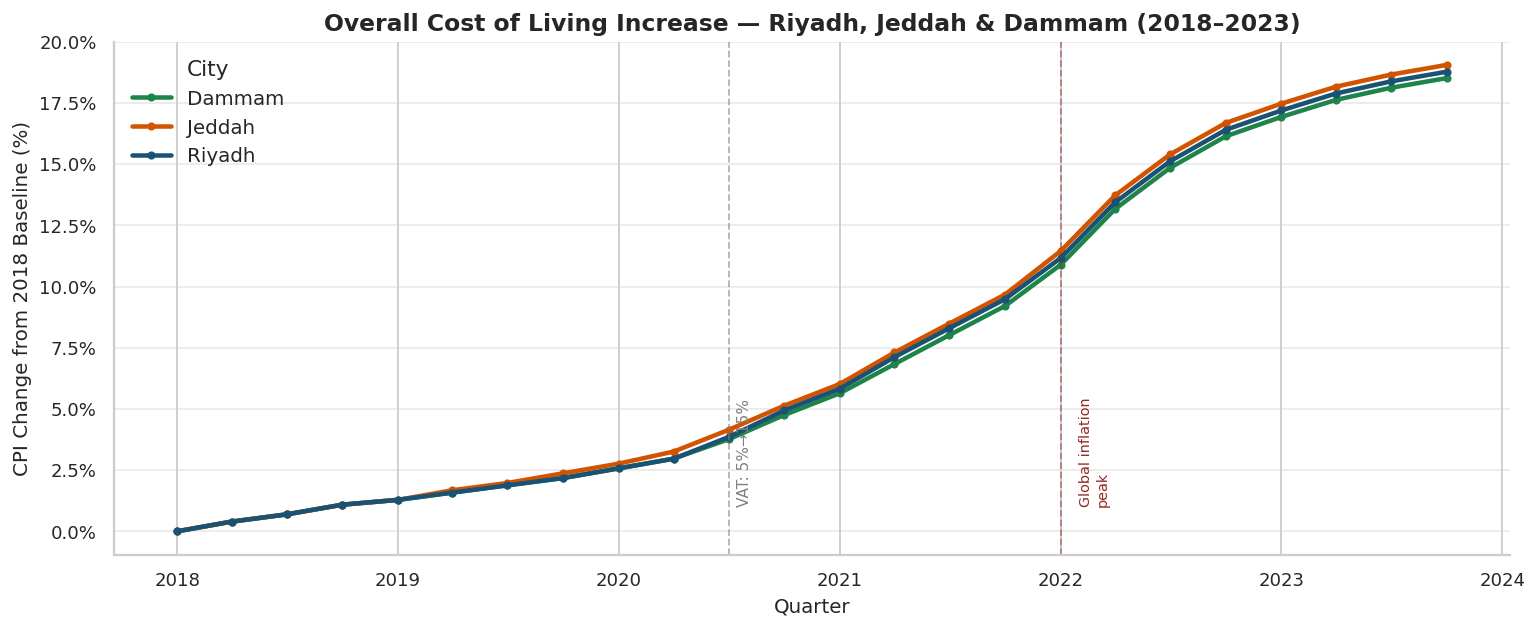

✓ Chart saved: 01_overall_cpi_trend.png


In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

for city, grp in df.groupby('city'):
    ax.plot(grp['date'], grp['overall_cpi_pct'],
            color=CITY_COLORS[city], linewidth=2.5, label=city, marker='o',
            markersize=3.5)

# Annotate key events
ax.axvline(pd.Timestamp('2020-07-01'), color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax.text(pd.Timestamp('2020-07-15'), 1.0, 'VAT: 5%→15%', fontsize=8.5,
        color='gray', rotation=90, va='bottom')

ax.axvline(pd.Timestamp('2022-01-01'), color='#922B21', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2022-02-01'), 1.0, 'Global inflation\npeak', fontsize=8,
        color='#922B21', rotation=90, va='bottom')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title('Overall Cost of Living Increase — Riyadh, Jeddah & Dammam (2018–2023)')
ax.set_xlabel('Quarter')
ax.set_ylabel('CPI Change from 2018 Baseline (%)')
ax.legend(title='City', frameon=False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('01_overall_cpi_trend.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved: 01_overall_cpi_trend.png")

# ── CELL 5: Category inflation comparison ────────────────────────────────────
"""
## Analysis 2 — Which Category Inflated Fastest?

Not all prices rise equally. The 2020 VAT increase hit everything, but
some categories — particularly food and transport — were also hit by
global commodity shocks in 2021–2022.

Education, by contrast, is heavily subsidised in Saudi Arabia, which
explains its near-flat trajectory.

We compare the **total percentage rise** for each category by 2023 Q4
averaged across all three cities.
"""

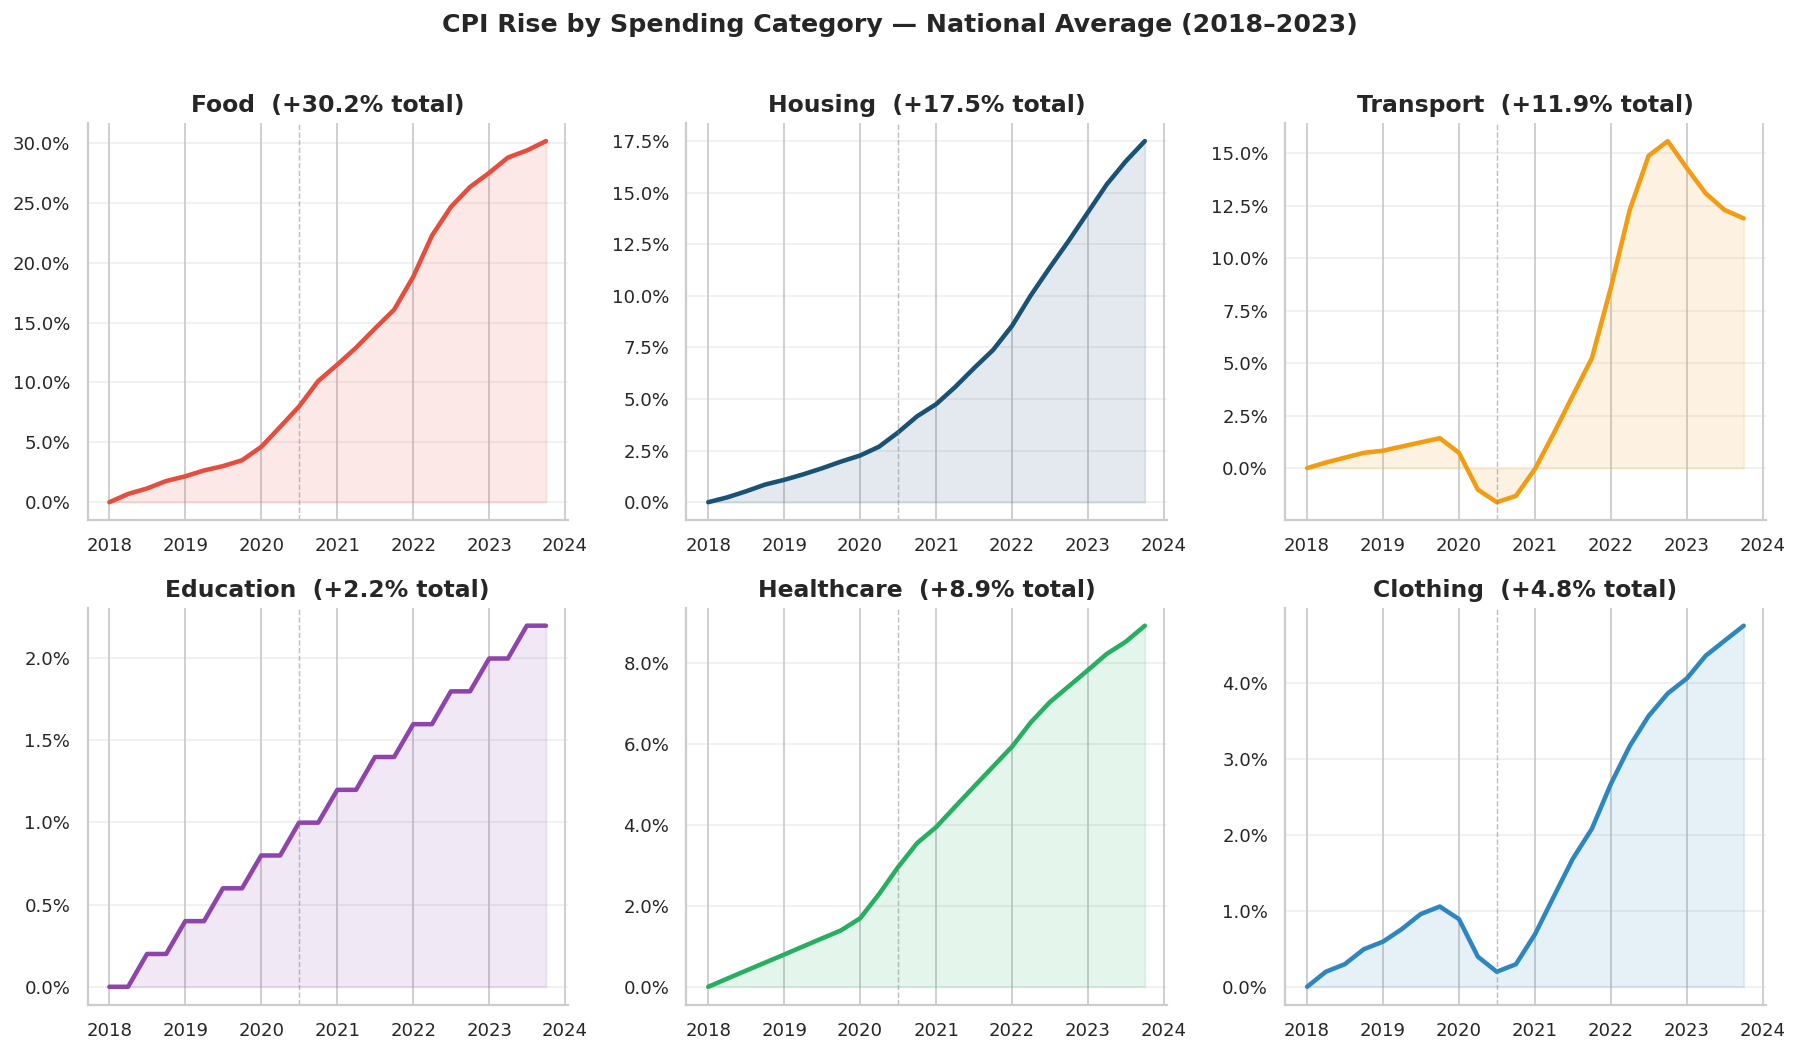

✓ Chart saved: 02_category_inflation.png


In [21]:
# National average (mean of 3 cities) per period
national = df.groupby('date')[[f'{c}_pct' for c in categories]].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(categories):
    ax = axes[i]
    ax.plot(national['date'], national[f'{cat}_pct'],
            color=CAT_COLORS[cat], linewidth=2.5)
    ax.fill_between(national['date'], national[f'{cat}_pct'],
                    alpha=0.12, color=CAT_COLORS[cat])
    final_val = national[f'{cat}_pct'].iloc[-1]
    ax.set_title(f'{cat.capitalize()}  (+{final_val:.1f}% total)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
    ax.axvline(pd.Timestamp('2020-07-01'), color='gray',
               linestyle='--', alpha=0.5, linewidth=0.8)

fig.suptitle('CPI Rise by Spending Category — National Average (2018–2023)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_category_inflation.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved: 02_category_inflation.png")

# ── CELL 6: City comparison bar chart (2023) ─────────────────────────────────
"""
## Analysis 3 — City Comparison: Who Paid More by 2023?

By the end of 2023, how much more expensive was each city compared to 2018?
This chart breaks the total inflation down by category for each city,
making it easy to see where the differences lie.

**Notable pattern:** Jeddah shows higher housing inflation — consistent
with its position as Saudi Arabia's commercial and tourism hub, where
real estate demand has risen sharply under Vision 2030 development.
"""

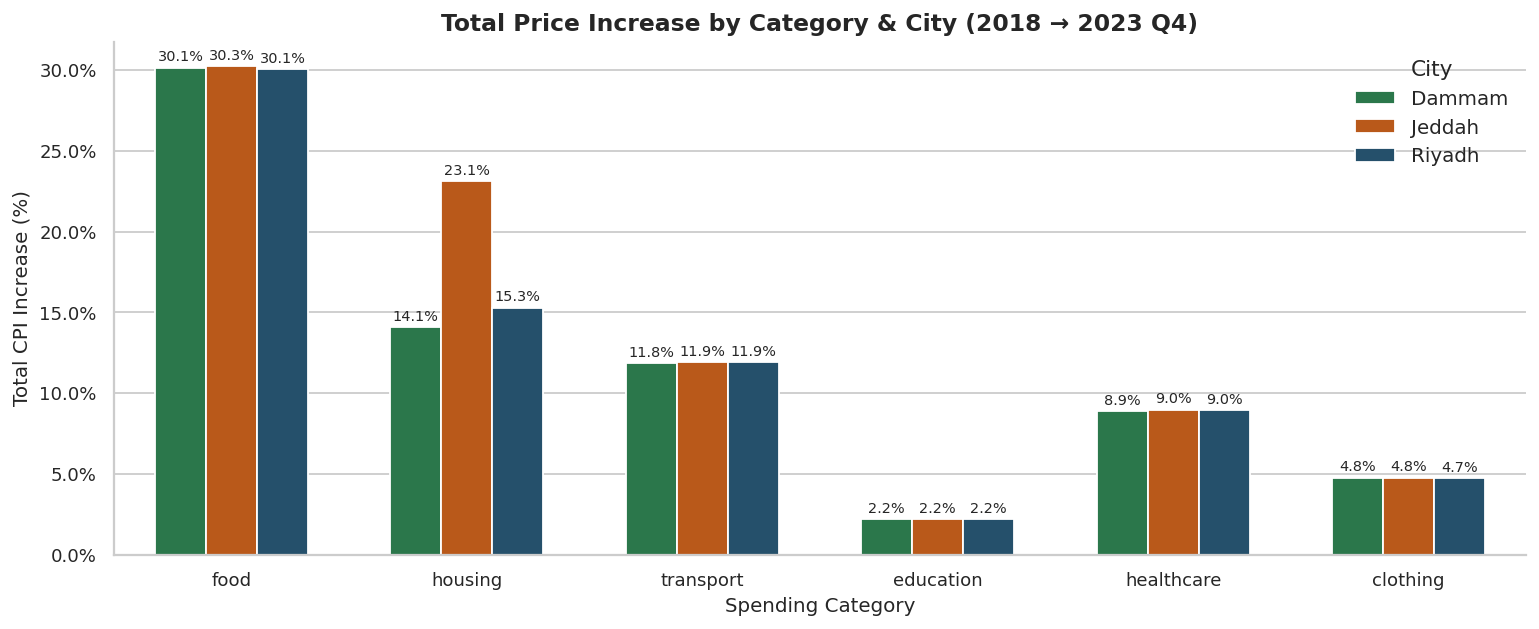

✓ Chart saved: 03_city_category_comparison.png


In [22]:
final = df[df['period'] == '2023-Q4'][
    ['city'] + [f'{c}_pct' for c in categories]
].copy()
final.columns = ['city'] + categories
final_melted = final.melt(id_vars='city', var_name='category', value_name='pct_change')

fig, ax = plt.subplots(figsize=(12, 5))
bar_plot = sns.barplot(
    data=final_melted,
    x='category', y='pct_change',
    hue='city',
    palette=CITY_COLORS,
    ax=ax,
    width=0.65
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title('Total Price Increase by Category & City (2018 → 2023 Q4)')
ax.set_xlabel('Spending Category')
ax.set_ylabel('Total CPI Increase (%)')
ax.legend(title='City', frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('03_city_category_comparison.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved: 03_city_category_comparison.png")

# ── CELL 7: COVID & VAT shock zoom-in ────────────────────────────────────────
"""
## Analysis 4 — The COVID & VAT Shock (2019 Q4 → 2021 Q4)

July 2020 was a turning point: Saudi Arabia tripled VAT from 5% to 15%
to offset oil revenue losses from COVID-19. This analysis zooms into the
shock period to quantify its immediate impact on each category.

Transport is the outlier — it initially *fell* in early 2020 as oil prices
collapsed and mobility declined, before rebounding sharply in 2021 as
travel resumed and global fuel prices surged.
"""

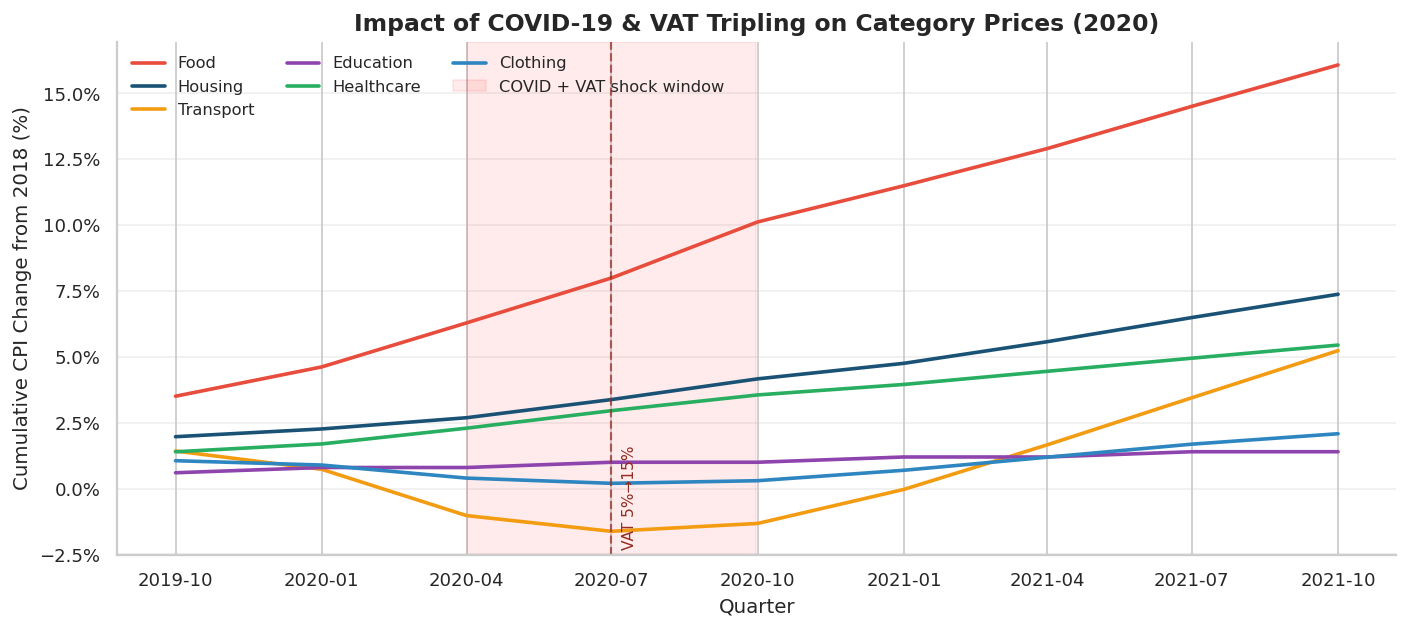

✓ Chart saved: 04_covid_vat_shock.png


In [23]:
shock = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2021-12-01')]
national_shock = shock.groupby('date')[[f'{c}_pct' for c in categories]].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))

for cat in categories:
    ax.plot(national_shock['date'], national_shock[f'{cat}_pct'],
            label=cat.capitalize(), linewidth=2, color=CAT_COLORS[cat])

ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2020-09-30'),
           alpha=0.08, color='red', label='COVID + VAT shock window')
ax.axvline(pd.Timestamp('2020-07-01'), color='#922B21',
           linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(pd.Timestamp('2020-07-08'), ax.get_ylim()[0] + 0.3,
        'VAT 5%→15%', fontsize=8.5, color='#922B21', rotation=90)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title('Impact of COVID-19 & VAT Tripling on Category Prices (2020)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Cumulative CPI Change from 2018 (%)')
ax.legend(frameon=False, ncol=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('04_covid_vat_shock.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved: 04_covid_vat_shock.png")

# ── CELL 8: Heatmap — all categories all years ───────────────────────────────
"""
## Analysis 5 — Inflation Heatmap: Every Category, Every Year

A heatmap gives the clearest summary picture: darker red = higher inflation
that year relative to the prior year. This is the "at a glance" chart —
the kind that works well in a presentation or Power BI dashboard summary page.
"""

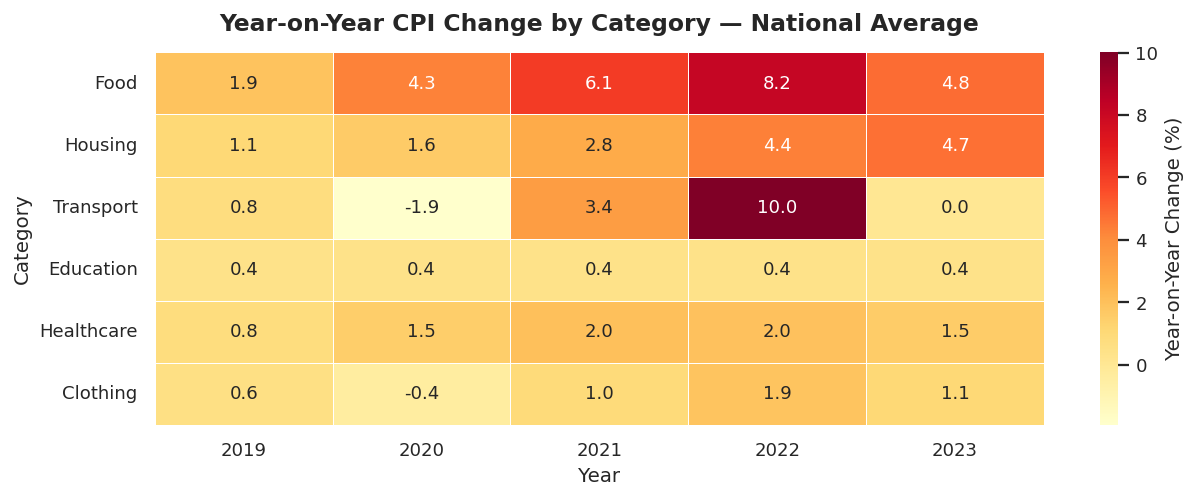

✓ Chart saved: 05_inflation_heatmap.png


In [24]:
annual = df.groupby(['year', 'city'])[categories].mean().reset_index()
national_annual = annual.groupby('year')[categories].mean()

# Calculate year-on-year % change
yoy = national_annual.pct_change() * 100
yoy = yoy.dropna()
yoy.columns = [c.capitalize() for c in yoy.columns]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    yoy.T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Year-on-Year Change (%)'},
    annot_kws={'size': 10}
)
ax.set_title('Year-on-Year CPI Change by Category — National Average', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('05_inflation_heatmap.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved: 05_inflation_heatmap.png")

# ── CELL 9: Riyadh vs Jeddah deep-dive ───────────────────────────────────────
"""
## Analysis 6 — Riyadh vs Jeddah: A Tale of Two Cities

Both cities follow similar macro trends, but the gap in housing costs
tells a different story. Jeddah's housing CPI rose significantly faster —
driven by the city's coastal tourism boom, new entertainment districts,
and Vision 2030 megaprojects anchored along the Red Sea coast.

Riyadh, while experiencing strong demand as the capital, benefits from
more abundant land supply in its desert surroundings.
"""

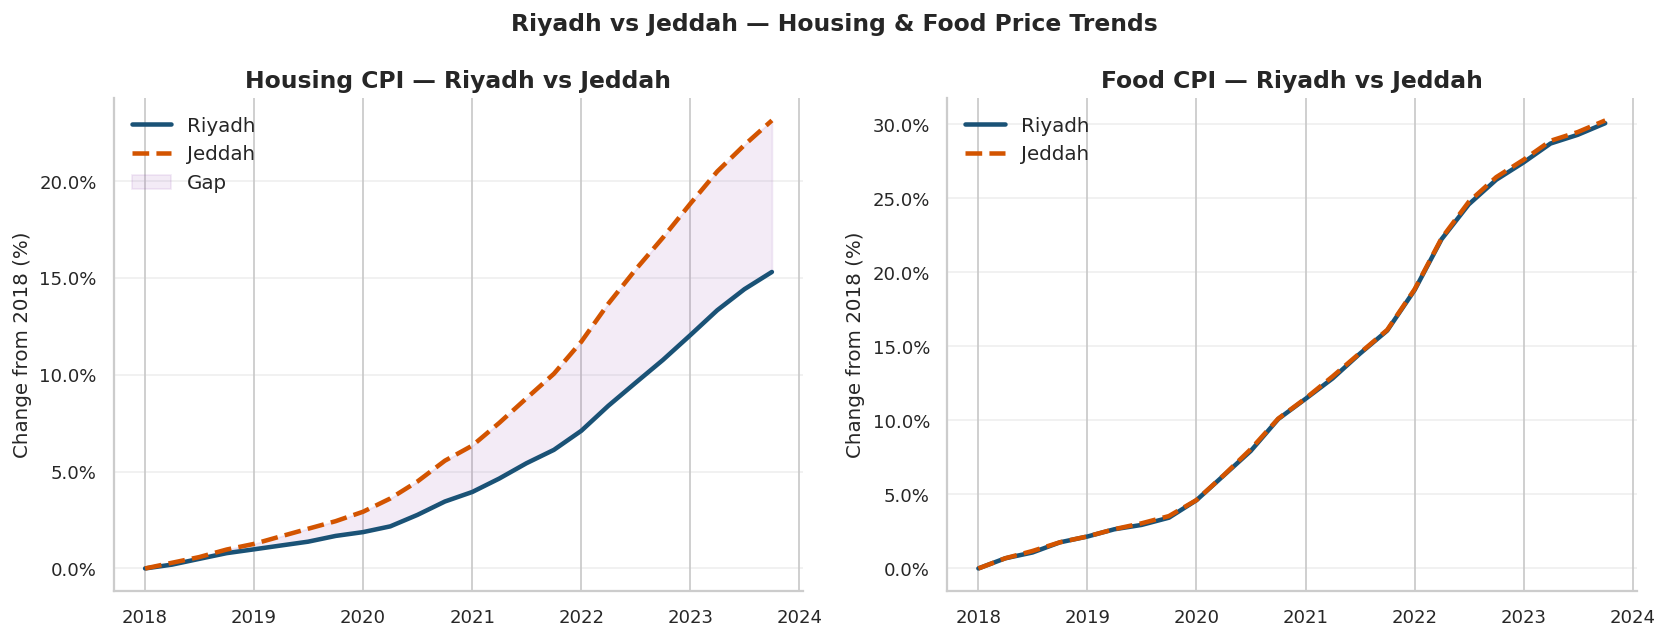

✓ Chart saved: 06_riyadh_vs_jeddah.png


In [25]:
ruh = df[df['city'] == 'Riyadh']
jed = df[df['city'] == 'Jeddah']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Housing comparison
axes[0].plot(ruh['date'], ruh['housing_pct'],
             color=CITY_COLORS['Riyadh'], linewidth=2.5, label='Riyadh')
axes[0].plot(jed['date'], jed['housing_pct'],
             color=CITY_COLORS['Jeddah'], linewidth=2.5, label='Jeddah', linestyle='--')
axes[0].fill_between(ruh['date'],
                     ruh['housing_pct'], jed['housing_pct'],
                     alpha=0.1, color='#8E44AD', label='Gap')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
axes[0].set_title('Housing CPI — Riyadh vs Jeddah')
axes[0].set_ylabel('Change from 2018 (%)')
axes[0].legend(frameon=False)
axes[0].grid(axis='y', alpha=0.3)

# Food comparison
axes[1].plot(ruh['date'], ruh['food_pct'],
             color=CITY_COLORS['Riyadh'], linewidth=2.5, label='Riyadh')
axes[1].plot(jed['date'], jed['food_pct'],
             color=CITY_COLORS['Jeddah'], linewidth=2.5, label='Jeddah', linestyle='--')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
axes[1].set_title('Food CPI — Riyadh vs Jeddah')
axes[1].set_ylabel('Change from 2018 (%)')
axes[1].legend(frameon=False)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Riyadh vs Jeddah — Housing & Food Price Trends',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_riyadh_vs_jeddah.png', bbox_inches='tight')
plt.show()
print("✓ Chart saved: 06_riyadh_vs_jeddah.png")

# ── CELL 10: Key findings summary ────────────────────────────────────────────
"""
## Summary of Key Findings

This cell prints a clean analytical summary — the kind you would write
as the conclusion of a report or the notes panel of a Power BI dashboard.
"""

In [26]:
print("=" * 62)
print("  SAUDI COST OF LIVING ANALYSIS — KEY FINDINGS (2018–2023)")
print("=" * 62)

final_national = df[df['period'] == '2023-Q4'].groupby('city')[
    [f'{c}_pct' for c in categories] + ['overall_cpi_pct']
].mean()

print("\n📊 TOTAL INFLATION BY CATEGORY (national average, 2018→2023)")
print("-" * 45)
for cat in categories:
    avg = df[df['period'] == '2023-Q4'][f'{cat}_pct'].mean()
    bar = '█' * int(avg / 1.5)
    print(f"  {cat.capitalize():<14} {avg:>5.1f}%  {bar}")

print("\n🏙️  OVERALL INFLATION BY CITY (2018→2023)")
print("-" * 45)
for city in ['Riyadh', 'Jeddah', 'Dammam']:
    val = df[(df['city'] == city) & (df['period'] == '2023-Q4')]['overall_cpi_pct'].values[0]
    print(f"  {city:<10} +{val:.1f}%")

print("\n⚡ TOP INSIGHTS")
print("-" * 45)

food_max = df[df['period'] == '2023-Q4']['food_pct'].mean()
housing_jed = df[(df['city'] == 'Jeddah') & (df['period'] == '2023-Q4')]['housing_pct'].values[0]
housing_ruh = df[(df['city'] == 'Riyadh') & (df['period'] == '2023-Q4')]['housing_pct'].values[0]
edu_max = df[df['period'] == '2023-Q4']['education_pct'].mean()
transport_2020 = df[(df['period'] == '2020-Q2')]['transport_pct'].mean()
transport_2022 = df[(df['period'] == '2022-Q3')]['transport_pct'].mean()

print(f"  1. Food was the fastest-inflating category at +{food_max:.1f}%,")
print(f"     driven by global supply chain disruption and the VAT increase.")
print(f"  2. Jeddah housing rose +{housing_jed:.1f}% vs Riyadh's +{housing_ruh:.1f}%,")
print(f"     reflecting Vision 2030 coastal development demand.")
print(f"  3. Education barely moved (+{edu_max:.1f}%) — Saudi government")
print(f"     subsidies kept this category near-flat throughout.")
print(f"  4. Transport dipped to {transport_2020:.1f}% change in Q2 2020 as")
print(f"     oil prices collapsed, then surged to +{transport_2022:.1f}% by 2022 Q3.")
print(f"  5. The 2022 global inflation wave is clearly visible across")
print(f"     all categories — the steepest 12-month rise in the dataset.")

print("\n✓ Analysis complete. Charts saved as PNG files.")
print("  Upload the .py file and PNG charts to GitHub.")

  SAUDI COST OF LIVING ANALYSIS — KEY FINDINGS (2018–2023)

📊 TOTAL INFLATION BY CATEGORY (national average, 2018→2023)
---------------------------------------------
  Food            30.2%  ████████████████████
  Housing         17.5%  ███████████
  Transport       11.9%  ███████
  Education        2.2%  █
  Healthcare       8.9%  █████
  Clothing         4.8%  ███

🏙️  OVERALL INFLATION BY CITY (2018→2023)
---------------------------------------------
  Riyadh     +18.8%
  Jeddah     +19.1%
  Dammam     +18.5%

⚡ TOP INSIGHTS
---------------------------------------------
  1. Food was the fastest-inflating category at +30.2%,
     driven by global supply chain disruption and the VAT increase.
  2. Jeddah housing rose +23.1% vs Riyadh's +15.3%,
     reflecting Vision 2030 coastal development demand.
  3. Education barely moved (+2.2%) — Saudi government
     subsidies kept this category near-flat throughout.
  4. Transport dipped to -1.0% change in Q2 2020 as
     oil prices collapsed